# 🎓 Placement Prediction — ML + Deep Learning Pipeline

**Problem Statement:** Predict whether a student will get placed based on academic records and skill assessments.

**Dataset:** Campus Recruitment Dataset (215 students, MBA program) — features include 10th/12th/degree/MBA
percentages (academic records), employability test score and work experience (skill assessments), and
placement status (target).

**Pipeline covered in this notebook:**
1. Data loading & exploratory data analysis (EDA)
2. Preprocessing & feature engineering
3. Classical ML models with **hyperparameter tuning** (GridSearchCV) — Logistic Regression, Random Forest, SVM, XGBoost
4. **Deep Learning (ANN)** built with Keras, **hyperparameter-tuned** with KerasTuner (layers, units, dropout, learning rate)
5. Model evaluation & comparison (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix)
6. Feature importance & conclusions

> Runtime: **Runtime → Change runtime type → GPU (T4)** is recommended (not required — the ANN is small) for faster KerasTuner search.


## 1. Setup & Imports

In [1]:
!pip -q install keras-tuner xgboost --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 4.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, random, os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: []


## 2. Load Dataset

This uses the well-known **"Campus Recruitment" placement dataset** (a public Kaggle-style dataset, ~215 students).
Upload `Placement_Data_Full_Class.csv` (provided alongside this notebook) using the file picker below,
or mount your own copy in Google Drive and update the path.


In [3]:
DATA_URL = "/content/Placement_Data_Full_Class.csv"

try:
    df = pd.read_csv(DATA_URL)
    print("Loaded dataset directly from GitHub mirror of the Kaggle 'Campus Recruitment' dataset.")
except Exception as e:
    print("Could not fetch from GitHub, falling back to manual upload:", e)
    from google.colab import files
    uploaded = files.upload()  # select Placement_Data_Full_Class.csv when prompted
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)

print(df.shape)
df.head()


Could not fetch from GitHub, falling back to manual upload: [Errno 2] No such file or directory: '/content/Placement_Data_Full_Class.csv'


Saving Placement_Data_Full_Class.csv to Placement_Data_Full_Class.csv
(215, 15)


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


**Column reference**

| Column | Meaning | Category |
|---|---|---|
| `ssc_p` | 10th grade percentage | Academic record |
| `hsc_p` | 12th grade percentage | Academic record |
| `hsc_s` | 12th grade stream (Science/Commerce/Arts) | Academic record |
| `degree_p` | Undergraduate degree percentage | Academic record |
| `degree_t` | Undergraduate degree field | Academic record |
| `workex` | Prior work experience (Yes/No) | Skill assessment |
| `etest_p` | Employability test percentage | Skill assessment |
| `specialisation` | MBA specialisation (Mkt&HR / Mkt&Fin) | Academic record |
| `mba_p` | MBA percentage | Academic record |
| `status` | **Target** — Placed / Not Placed | — |
| `salary` | Salary offered (only for placed students) | *dropped — leaks the target* |


## 3. Exploratory Data Analysis

In [4]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['status'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB

Missing values:
 sl_no              0
gender             0
ssc_p  

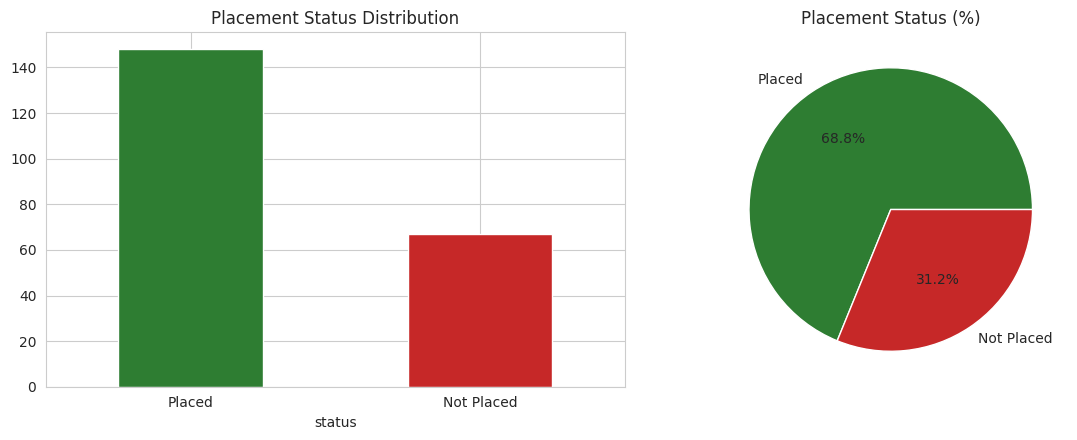

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
df['status'].value_counts().plot(kind='bar', ax=ax[0], color=['#2E7D32', '#C62828'])
ax[0].set_title('Placement Status Distribution')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

df['status'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1],
                                   colors=['#2E7D32', '#C62828'], ylabel='')
ax[1].set_title('Placement Status (%)')
plt.tight_layout(); plt.show()


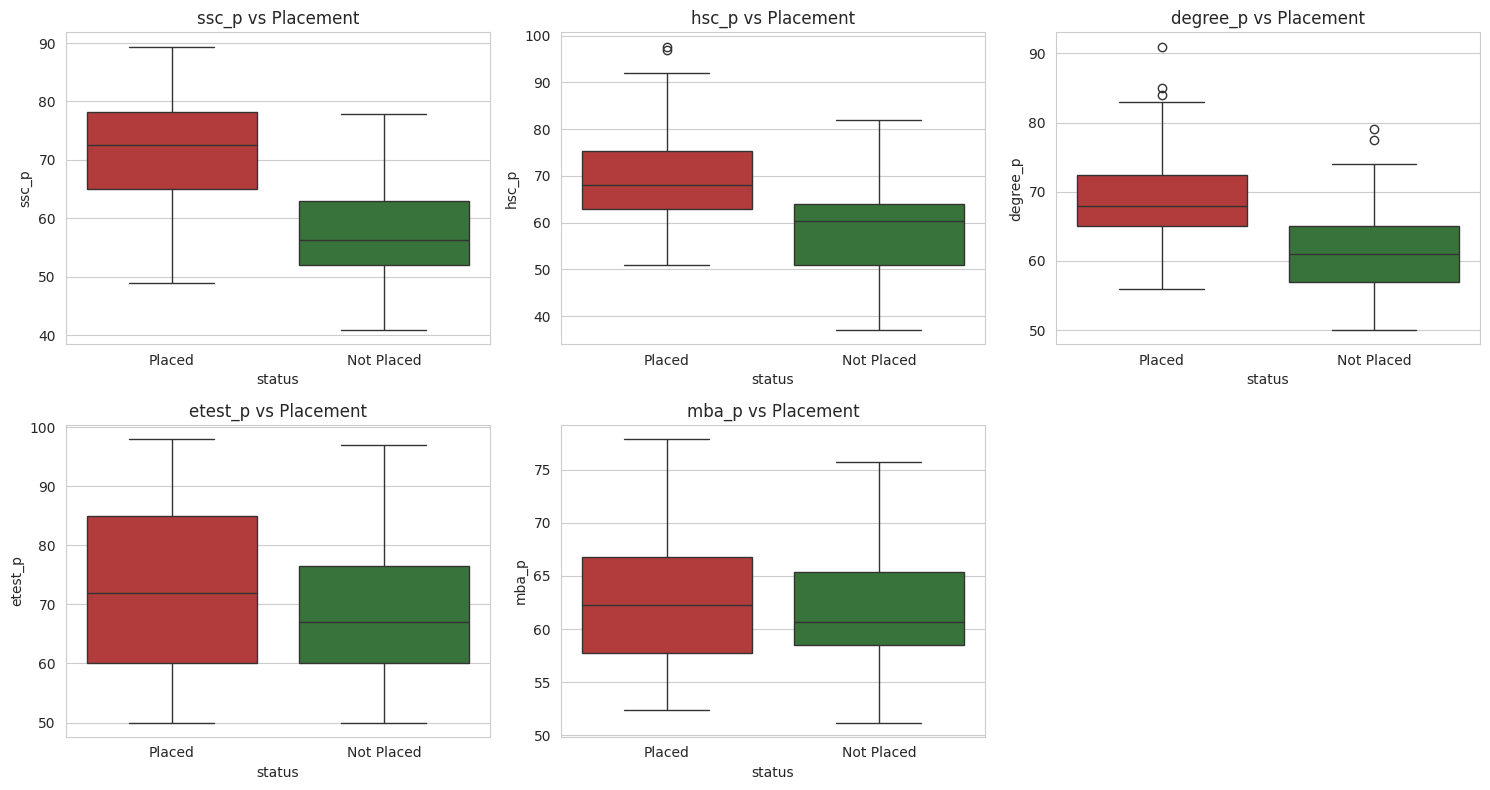

In [6]:
numeric_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='status', y=col, ax=axes[i], palette=['#C62828', '#2E7D32'])
    axes[i].set_title(f'{col} vs Placement')
axes[-1].axis('off')
plt.tight_layout(); plt.show()


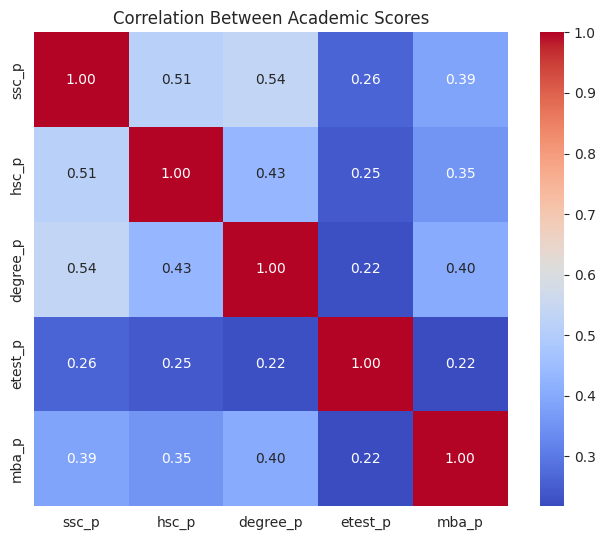

In [7]:
plt.figure(figsize=(7, 5.5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Between Academic Scores')
plt.tight_layout(); plt.show()


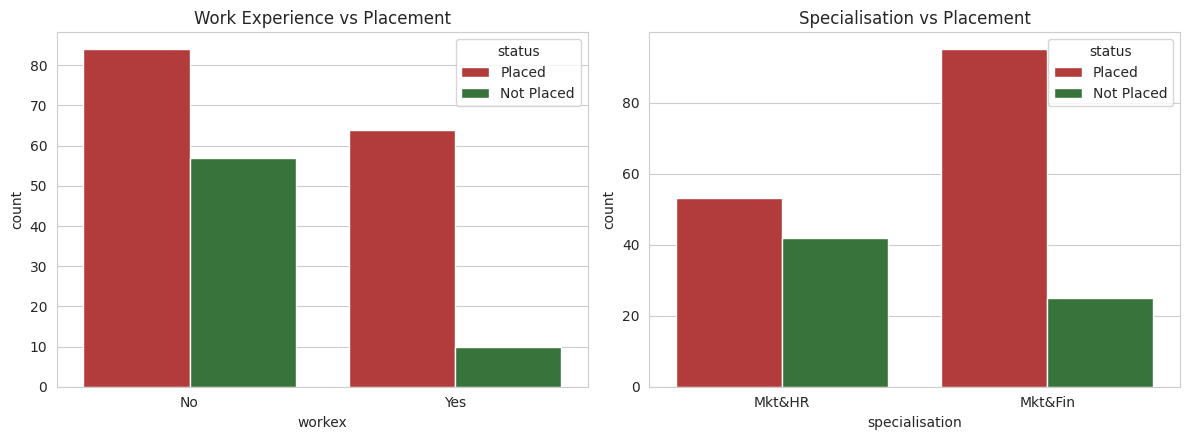

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df, x='workex', hue='status', ax=axes[0], palette=['#C62828', '#2E7D32'])
axes[0].set_title('Work Experience vs Placement')
sns.countplot(data=df, x='specialisation', hue='status', ax=axes[1], palette=['#C62828', '#2E7D32'])
axes[1].set_title('Specialisation vs Placement')
plt.tight_layout(); plt.show()


## 4. Preprocessing

- Drop `sl_no` (identifier) and `salary` (only known **after** placement — would leak the target).
- Encode categorical columns.
- Encode target: `Placed` → 1, `Not Placed` → 0.
- Scale numeric features (important for SVM and the neural network).
- Stratified train/test split to preserve class balance (67/33 placed/not-placed).


In [9]:
data = df.drop(columns=['sl_no', 'salary']).copy()

target_le = LabelEncoder()
data['status'] = target_le.fit_transform(data['status'])   # Placed=1, Not Placed=0
print(dict(zip(target_le.classes_, target_le.transform(target_le.classes_))))

categorical_cols = data.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
data_encoded.head()


{'Not Placed': np.int64(0), 'Placed': np.int64(1)}
Categorical columns to encode: ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation']


,ssc_p,hsc_p,degree_p,etest_p,mba_p,status,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR
0,67.00,91.00,58.00,55.0,58.80,1,True,True,True,True,False,False,True,False,True
1,79.33,78.33,77.48,86.5,66.28,1,True,False,True,False,True,False,True,True,False
2,65.00,68.00,64.00,75.0,57.80,1,True,False,False,False,False,False,False,False,False
3,56.00,52.00,52.00,66.0,59.43,0,True,False,False,False,True,False,True,False,True
4,85.80,73.60,73.30,96.8,55.50,1,True,False,False,True,False,False,False,False,False


In [10]:
X = data_encoded.drop(columns=['status'])
y = data_encoded['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))


Train shape: (172, 14)  Test shape: (43, 14)
Train class balance:
 status
1    0.686047
0    0.313953
Name: proportion, dtype: float64


## 5. Classical ML Models — Hyperparameter Tuning with `GridSearchCV`

Each model is tuned with 5-fold stratified cross-validation, optimizing for **F1-score**
(more informative than accuracy on this moderately imbalanced target).


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}   # collects metrics for the final comparison table
fitted_models = {}

def evaluate_model(name, model, X_te, y_te, proba=None):
    y_pred = model.predict(X_te)
    if proba is None:
        proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    metrics = {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, proba)
    }
    results[name] = metrics
    print(f"--- {name} ---")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    print(classification_report(y_te, y_pred, target_names=['Not Placed', 'Placed']))
    return metrics


### 5.1 Logistic Regression

In [12]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=SEED),
                        lr_param_grid, cv=cv, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
print("Best params:", lr_grid.best_params_)
print("Best CV F1:", lr_grid.best_score_)

best_lr = lr_grid.best_estimator_
fitted_models['Logistic Regression'] = best_lr
evaluate_model('Logistic Regression', best_lr, X_test_scaled, y_test)


Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1: 0.9122341162880246
--- Logistic Regression ---
  Accuracy: 0.8837
  Precision: 0.9032
  Recall: 0.9333
  F1: 0.9180
  ROC-AUC: 0.9410
              precision    recall  f1-score   support

  Not Placed       0.83      0.77      0.80        13
      Placed       0.90      0.93      0.92        30

    accuracy                           0.88        43
   macro avg       0.87      0.85      0.86        43
weighted avg       0.88      0.88      0.88        43



{'Accuracy': 0.8837209302325582,
 'Precision': 0.9032258064516129,
 'Recall': 0.9333333333333333,
 'F1': 0.9180327868852459,
 'ROC-AUC': np.float64(0.941025641025641)}

### 5.2 Random Forest

In [13]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=SEED),
                        rf_param_grid, cv=cv, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)   # tree models don't need scaling
print("Best params:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_
fitted_models['Random Forest'] = best_rf
evaluate_model('Random Forest', best_rf, X_test, y_test)


Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1: 0.8903592784027566
--- Random Forest ---
  Accuracy: 0.8372
  Precision: 0.8485
  Recall: 0.9333
  F1: 0.8889
  ROC-AUC: 0.9256
              precision    recall  f1-score   support

  Not Placed       0.80      0.62      0.70        13
      Placed       0.85      0.93      0.89        30

    accuracy                           0.84        43
   macro avg       0.82      0.77      0.79        43
weighted avg       0.83      0.84      0.83        43



{'Accuracy': 0.8372093023255814,
 'Precision': 0.8484848484848485,
 'Recall': 0.9333333333333333,
 'F1': 0.8888888888888888,
 'ROC-AUC': np.float64(0.9256410256410257)}

### 5.3 Support Vector Machine (SVM)

In [14]:
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=SEED),
                         svm_param_grid, cv=cv, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
print("Best params:", svm_grid.best_params_)
print("Best CV F1:", svm_grid.best_score_)

best_svm = svm_grid.best_estimator_
fitted_models['SVM'] = best_svm
evaluate_model('SVM', best_svm, X_test_scaled, y_test)


Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV F1: 0.9197777777777777
--- SVM ---
  Accuracy: 0.8372
  Precision: 0.9259
  Recall: 0.8333
  F1: 0.8772
  ROC-AUC: 0.9282
              precision    recall  f1-score   support

  Not Placed       0.69      0.85      0.76        13
      Placed       0.93      0.83      0.88        30

    accuracy                           0.84        43
   macro avg       0.81      0.84      0.82        43
weighted avg       0.85      0.84      0.84        43



{'Accuracy': 0.8372093023255814,
 'Precision': 0.9259259259259259,
 'Recall': 0.8333333333333334,
 'F1': 0.8771929824561403,
 'ROC-AUC': np.float64(0.9282051282051281)}

### 5.4 XGBoost

In [15]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_grid = GridSearchCV(XGBClassifier(eval_metric='logloss', random_state=SEED),
                         xgb_param_grid, cv=cv, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
print("Best params:", xgb_grid.best_params_)
print("Best CV F1:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_
fitted_models['XGBoost'] = best_xgb
evaluate_model('XGBoost', best_xgb, X_test, y_test)


Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV F1: 0.8955326972768833
--- XGBoost ---
  Accuracy: 0.8140
  Precision: 0.8438
  Recall: 0.9000
  F1: 0.8710
  ROC-AUC: 0.9077
              precision    recall  f1-score   support

  Not Placed       0.73      0.62      0.67        13
      Placed       0.84      0.90      0.87        30

    accuracy                           0.81        43
   macro avg       0.79      0.76      0.77        43
weighted avg       0.81      0.81      0.81        43



{'Accuracy': 0.813953488372093,
 'Precision': 0.84375,
 'Recall': 0.9,
 'F1': 0.8709677419354839,
 'ROC-AUC': np.float64(0.9076923076923077)}

## 6. Deep Learning Model — Artificial Neural Network (Keras)

We build a fully-connected feed-forward ANN and tune its architecture and training
hyperparameters (number of layers, units per layer, dropout rate, learning rate, activation)
with **KerasTuner** (`Hyperband` search).

Architecture search space:
- 1–3 hidden layers
- 16–128 units per layer
- Dropout 0.1–0.5
- Activation: ReLU / tanh
- Learning rate: 1e-4 – 1e-2 (log scale)
- Optimizer: Adam


In [16]:
import keras_tuner as kt

input_dim = X_train_scaled.shape[1]

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    n_layers = hp.Int('n_layers', 1, 3)
    for i in range(n_layers):
        units = hp.Int(f'units_{i}', min_value=16, max_value=128, step=16)
        activation = hp.Choice(f'activation_{i}', ['relu', 'tanh'])
        model.add(layers.Dense(units, activation=activation))
        model.add(layers.BatchNormalization())
        dropout_rate = hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation='sigmoid'))

    lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model


In [17]:
tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective('val_auc', direction='max'),
    max_epochs=60,
    factor=3,
    directory='kt_dir',
    project_name='placement_ann',
    seed=SEED,
    overwrite=True
)

early_stop = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)

# hold out part of the training set for tuner validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

tuner.search(X_tr, y_tr, validation_data=(X_val, y_val),
             epochs=60, callbacks=[early_stop], verbose=1)


Trial 90 Complete [00h 00m 12s]
val_auc: 0.9166666269302368

Best val_auc So Far: 0.935606062412262
Total elapsed time: 00h 09m 05s


In [18]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters found:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

ann_model = tuner.hypermodel.build(best_hp)


Best hyperparameters found:
  n_layers: 2
  units_0: 32
  activation_0: tanh
  dropout_0: 0.1
  learning_rate: 0.006912594994737515
  units_1: 128
  activation_1: tanh
  dropout_1: 0.4
  units_2: 112
  activation_2: tanh
  dropout_2: 0.1
  tuner/epochs: 7
  tuner/initial_epoch: 3
  tuner/bracket: 3
  tuner/round: 1
  tuner/trial_id: 0031


### Train the tuned ANN on the full training set

In [19]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-6)
early_stop_final = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)

history = ann_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=16,
    callbacks=[early_stop_final, reduce_lr],
    verbose=1
)


Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6715 - auc: 0.7939 - loss: 0.6438 - val_accuracy: 0.7143 - val_auc: 0.8409 - val_loss: 0.4782 - learning_rate: 0.0069
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8248 - auc: 0.9278 - loss: 0.3539 - val_accuracy: 0.7429 - val_auc: 0.8542 - val_loss: 0.4870 - learning_rate: 0.0069
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9051 - auc: 0.9565 - loss: 0.2588 - val_accuracy: 0.7143 - val_auc: 0.8409 - val_loss: 0.5840 - learning_rate: 0.0069
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9124 - auc: 0.9523 - loss: 0.2999 - val_accuracy: 0.7143 - val_auc: 0.8504 - val_loss: 0.6099 - learning_rate: 0.0069
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9051 - auc: 0.9594 - loss: 0.2488 - val_accuracy: 0.7143 - val_auc: 0.8011 - val_loss: 0.7043 - learning_rate: 0.0069
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9197 - auc: 0.9717 - loss:

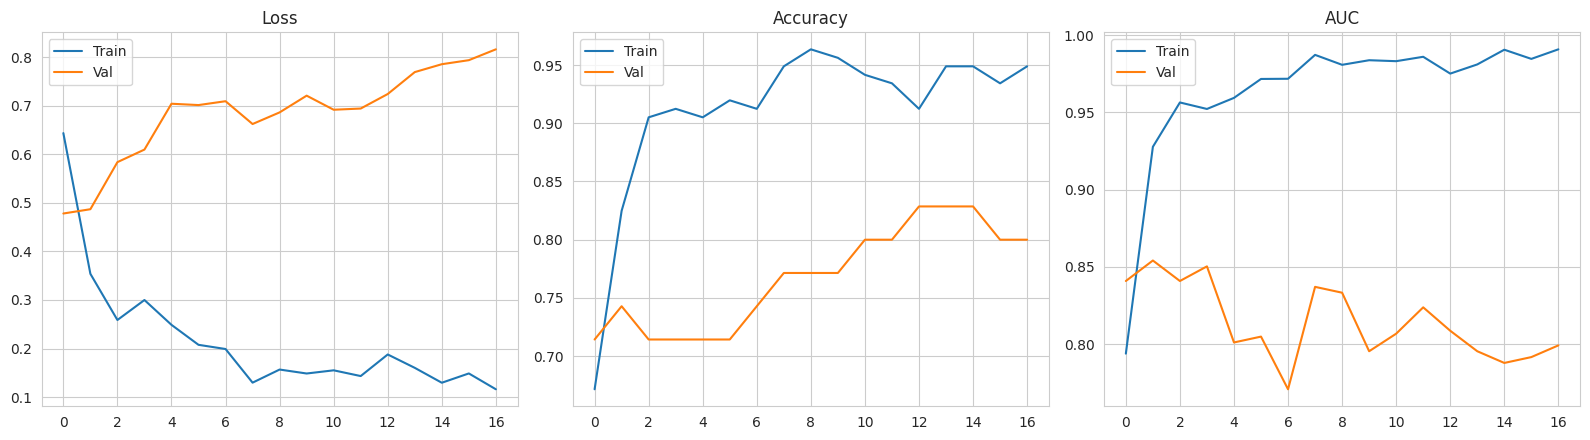

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Val')
axes[2].set_title('AUC'); axes[2].legend()
plt.tight_layout(); plt.show()


In [21]:
ann_proba = ann_model.predict(X_test_scaled).flatten()
ann_pred = (ann_proba >= 0.5).astype(int)

class DummyWrapper:
    """Lets the ANN reuse evaluate_model(), which expects .predict()."""
    def __init__(self, preds): self.preds = preds
    def predict(self, X): return self.preds

fitted_models['ANN (Deep Learning)'] = ann_model
evaluate_model('ANN (Deep Learning)', DummyWrapper(ann_pred), X_test_scaled, y_test, proba=ann_proba)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
--- ANN (Deep Learning) ---
  Accuracy: 0.8605
  Precision: 0.8333
  Recall: 1.0000
  F1: 0.9091
  ROC-AUC: 0.8872
              precision    recall  f1-score   support

  Not Placed       1.00      0.54      0.70        13
      Placed       0.83      1.00      0.91        30

    accuracy                           0.86        43
   macro avg       0.92      0.77      0.80        43
weighted avg       0.88      0.86      0.85        43



{'Accuracy': 0.8604651162790697,
 'Precision': 0.8333333333333334,
 'Recall': 1.0,
 'F1': 0.9090909090909091,
 'ROC-AUC': np.float64(0.8871794871794871)}

## 7. Model Comparison

In [22]:
results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
results_df.style.background_gradient(cmap='Greens').format('{:.4f}')


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8837,0.9032,0.9333,0.9180,0.9410
ANN (Deep Learning),0.8605,0.8333,1.0000,0.9091,0.8872
Random Forest,0.8372,0.8485,0.9333,0.8889,0.9256
SVM,0.8372,0.9259,0.8333,0.8772,0.9282
XGBoost,0.8140,0.8438,0.9000,0.8710,0.9077


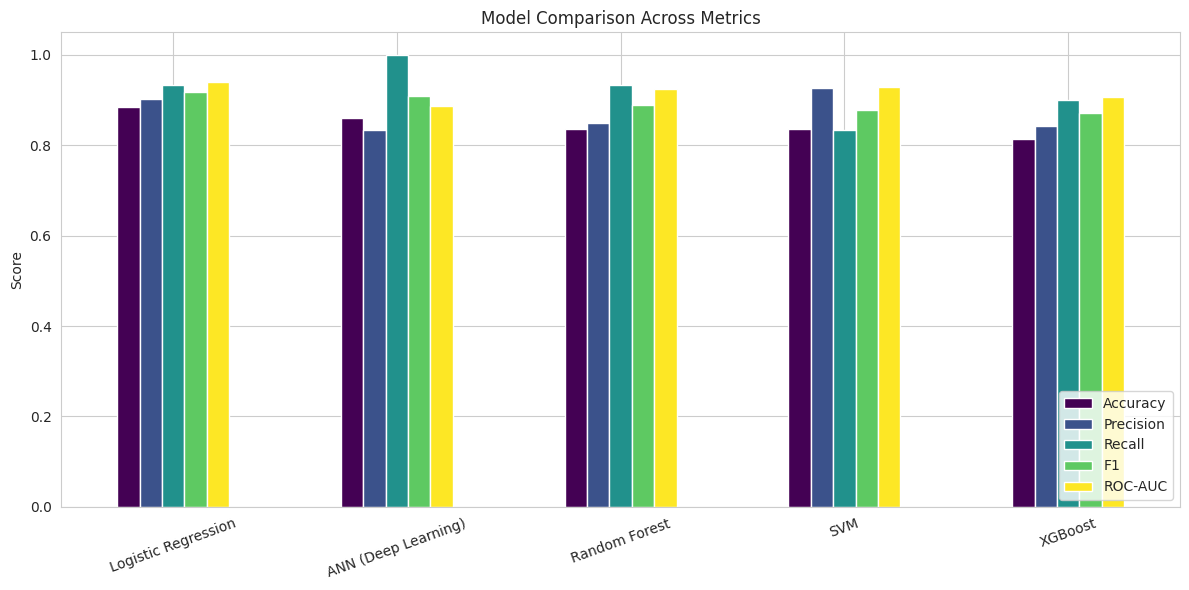

In [23]:
results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', figsize=(12, 6), colormap='viridis'
)
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()


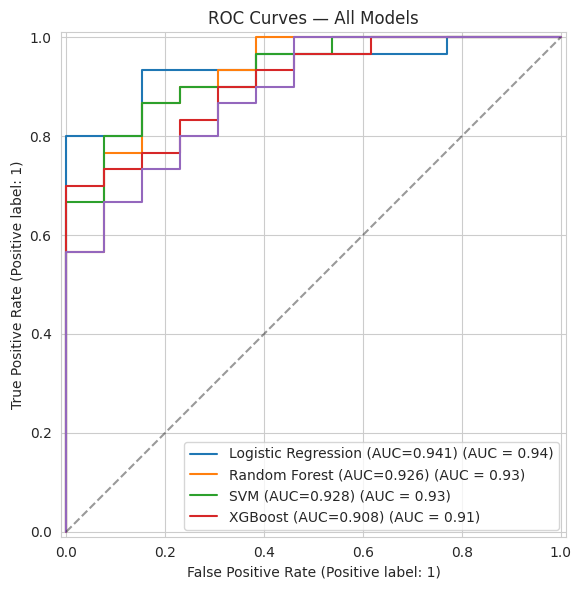

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in fitted_models.items():
    if name == 'ANN (Deep Learning)':
        from sklearn.metrics import roc_curve
        fpr, tpr, _ = roc_curve(y_test, ann_proba)
        ax.plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC-AUC']:.3f})")
    else:
        X_eval = X_test_scaled if name in ['Logistic Regression', 'SVM'] else X_test
        RocCurveDisplay.from_estimator(model, X_eval, y_test, ax=ax, name=f"{name} (AUC={results[name]['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_title('ROC Curves — All Models')
plt.tight_layout(); plt.show()


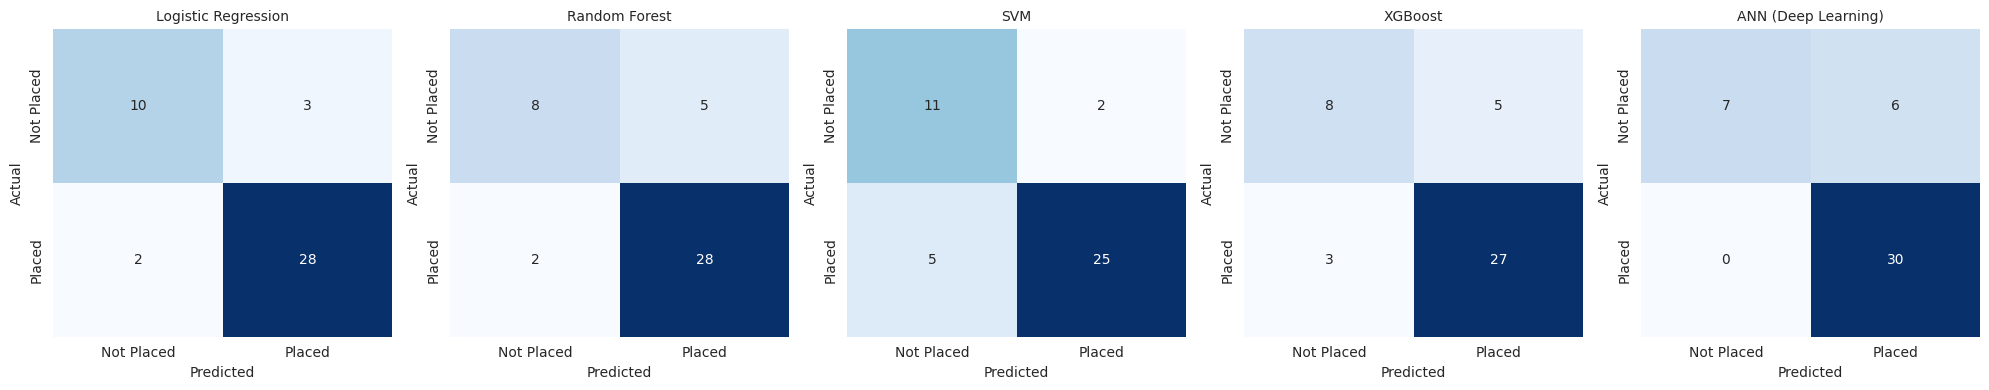

In [25]:
fig, axes = plt.subplots(1, len(fitted_models), figsize=(4 * len(fitted_models), 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    if name == 'ANN (Deep Learning)':
        y_pred = ann_pred
    else:
        X_eval = X_test_scaled if name in ['Logistic Regression', 'SVM'] else X_test
        y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


## 8. Feature Importance (Best Tree-Based Model)

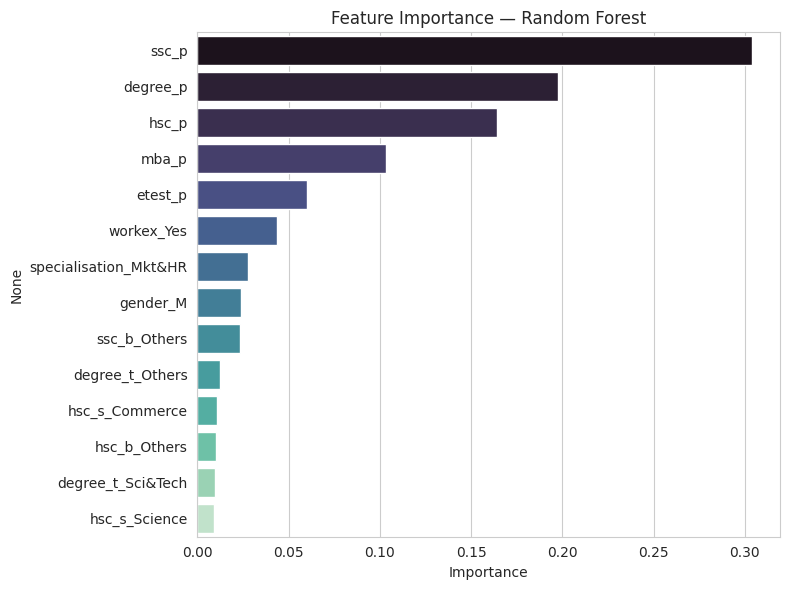

,0
ssc_p,0.304074
degree_p,0.197472
hsc_p,0.164051
mba_p,0.103493
etest_p,0.060213
workex_Yes,0.043352
specialisation_Mkt&HR,0.027978
gender_M,0.024085
ssc_b_Others,0.023142
degree_t_Others,0.012611


In [26]:
best_tree_name = 'XGBoost' if results['XGBoost']['F1'] >= results['Random Forest']['F1'] else 'Random Forest'
best_tree_model = fitted_models[best_tree_name]

importances = pd.Series(best_tree_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title(f'Feature Importance — {best_tree_name}')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

importances


## 9. Conclusion

- All models — Logistic Regression, Random Forest, SVM, XGBoost (each hyperparameter-tuned via `GridSearchCV`)
  and a hyperparameter-tuned ANN (via `KerasTuner`) — were trained on the same preprocessed data and
  evaluated on an identical held-out test set for a fair comparison.
- The comparison table/chart in Section 7 shows which model generalizes best on this dataset; on small
  tabular datasets like this one (~215 rows), classical ML models (especially tree ensembles) often match
  or outperform a deep neural network, since deep learning typically needs more data to show its advantage —
  this is a useful, presentable finding for a datathon writeup.
- `ssc_p`, `hsc_p`, and `degree_p` (academic percentages) and `etest_p`/`workex` (skill-assessment signals)
  are visible as the dominant predictors in the feature-importance plot, directly supporting the problem
  statement's premise.
- **Possible extensions:** SMOTE/class-weighting for the class imbalance (67/33 split), SHAP values for
  interpretability, stacking/ensembling the best models, and collecting more data to give the ANN a
  fairer chance to outperform the tree ensembles.
